# EDA

The files provided for the competition are:  

* train.csv - contains the training set  
* test.csv - contains the test set  
* sample_submission.csv - a sample submission of rating and recommendation predictions for each sample in the test set

The data fields are:

* Id: Review Id
* Age: Positive Integer variable of the reviewers age.
* Review_Title: String variable for the title of the review.
* Review: String variable for the review body.
* Pos_Feedback_Cnt: Positive Integer documenting the number of other customers who found this review positive.
* Division: Categorical name of the product high level division.
* Department: Categorical name of the product department name.
* Product_Category : Categorical name of the product class name.
* Rating: Positive Ordinal Integer variable for the product score granted by the customer from 1 Worst, to 5 Best. This is one of the target columns.
* Recommended: Binary variable stating where the customer recommends the product where 1 is recommended, 0 is not recommended. This is one of the target columns.

Завдання:
* Demonstration of applying classical NLP techniques to the text data, along with an explanation of how they were used in the model (if they were used) or why they weren't used (if they weren't)
* Demonstration of a Bag-of-Words model for the required task
* Demonstration of an RNN-based model for the required task

До класичних технік NLP відноситься попередня обробка тексту для подальшого навчання.  

* Tokenization - токенізація, розбиття наших речень на слова.  
* Lowercasing - приведення усіх літер до нижнього регістру.  
* Stop-words removal - видалення стоп-слів, які вважаються зайвим шумом.  
* Lemmatization - лематизація, приведення слів до початкової форми.  
* Stemming - стемінг, це теж приведення слів до початкової форми,  
але більш грубим підходом, закінчення/суфікси просто обрізаються.  
Працює звісно значно швидше за лематизацію, але часто створює неіснуючі слова.

Підхід Bag-of-Words, який дослівно перекладається як 'мішок слів',  
потребує наступних технік обробки:  
 * Токенізація  
 * Приведення до одного регістру  
 * Видалення стоп-слів  
 * Лематизація (стемінг тут використовувати не буду, оскільки обсяг даних  
   не є критично великим, і можемо собі дозволити зберегти словникову форму слів)  

Цей підхід не враховує послідовності слів.  
Він знає які слова існують в реченні, скільки разів там зустрічаються,  
але гадки не має у якій послідовності.
BoW зможе класифікувати відгук просто за наявністю хороших і поганих слів.
Цей підхід є простішим і швидшим за RNN модель.

RNN модель складніша, звертає увагу на послідовність слів, зберігає контекст.  
Може вловити складніші текстові конструкції.  
Тому до неї не буде застосовано видалення стоп-слів, оскільки це може порушити структуру речення.
Буде застосована наступна очистка:
 * Токенізація   
 * Приведення до одного регістру  
 * Лематизація

In [2]:
import pandas as pd
import numpy as np
import re
import spacy
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import category_encoders as ce

In [3]:
sub_ds = pd.read_csv('final-project-danit-ds-3-4/sample_submission.csv')
train_ds = pd.read_csv('final-project-danit-ds-3-4/train.csv')
test_ds = pd.read_csv('final-project-danit-ds-3-4/test.csv')

In [4]:
sub_ds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9395 entries, 0 to 9394
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Id           9395 non-null   int64
 1   Rating       9395 non-null   int64
 2   Recommended  9395 non-null   int64
dtypes: int64(3)
memory usage: 220.3 KB


In [5]:
sub_ds.head()

,Id,Rating,Recommended
0,21403,2,1
1,22553,5,0
2,17436,1,1
3,4293,1,0
4,20149,4,0


In [6]:
test_ds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9395 entries, 0 to 9394
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Id                9395 non-null   int64 
 1   Age               9395 non-null   int64 
 2   Review_Title      7944 non-null   object
 3   Review            9053 non-null   object
 4   Pos_Feedback_Cnt  9395 non-null   int64 
 5   Division          9392 non-null   object
 6   Department        9392 non-null   object
 7   Product_Category  9392 non-null   object
dtypes: int64(3), object(5)
memory usage: 587.3+ KB


In [7]:
test_ds.isna().sum()

Id                     0
Age                    0
Review_Title        1451
Review               342
Pos_Feedback_Cnt       0
Division               3
Department             3
Product_Category       3
dtype: int64

Перевіривши наш сабмішн файл та тестовий датасет можна помітити, що їх розміри однакові.  
Від нас очікують отримати сабмішн саме цієї розмірності - 9395 оцінок.  
Але ми маємо багато порожніх значень в ознаках Review_Title та Review.  
Це говорить про те, що частину буде передбачати модель яка буде вчитися читати саме відгуки.  
Для інших спробуємо робити передбачення спираючись на інші ознаки.

In [8]:
train_ds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14091 entries, 0 to 14090
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Id                14091 non-null  int64 
 1   Age               14091 non-null  int64 
 2   Review_Title      11732 non-null  object
 3   Review            13588 non-null  object
 4   Pos_Feedback_Cnt  14091 non-null  int64 
 5   Division          14080 non-null  object
 6   Department        14080 non-null  object
 7   Product_Category  14080 non-null  object
 8   Rating            14091 non-null  int64 
 9   Recommended       14091 non-null  int64 
dtypes: int64(5), object(5)
memory usage: 1.1+ MB


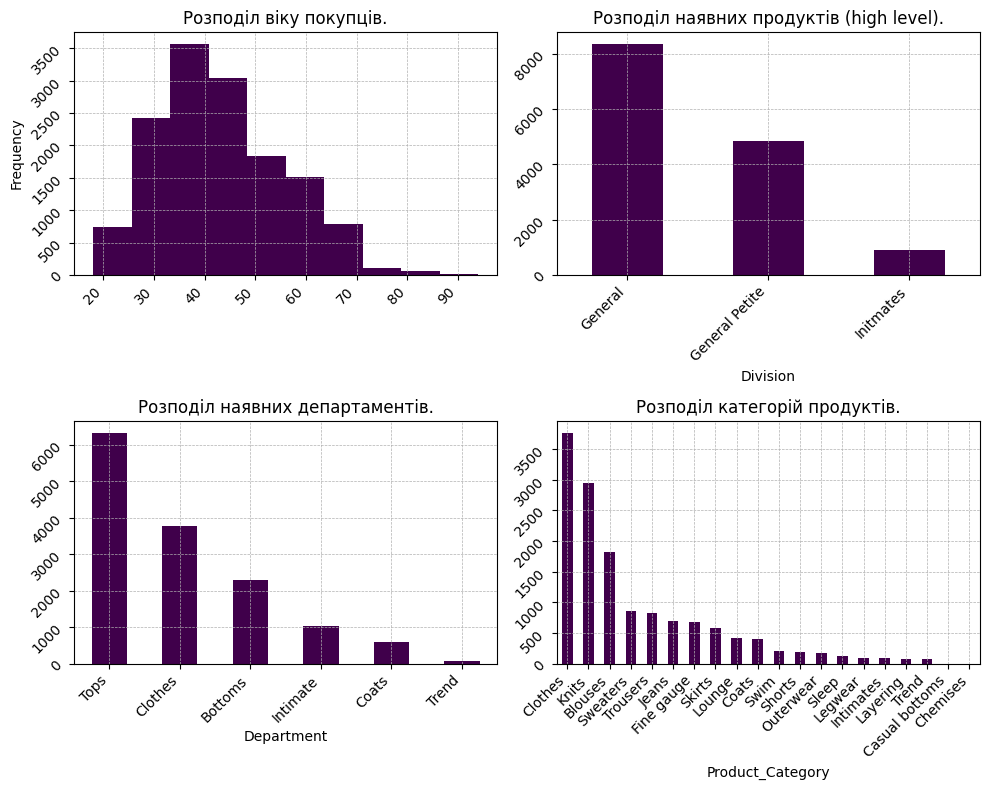

In [36]:
plt.figure(figsize=(10, 8))

plt.subplot(2, 2, 1)
plt.title('Розподіл віку покупців.')
train_ds['Age'].plot(kind='hist', cmap='PRGn')
plt.grid(linestyle = '--', linewidth = 0.5)
plt.yticks(rotation=45, ha="right")
plt.xticks(rotation=45, ha="right")

plt.subplot(2, 2, 2)
plt.title('Розподіл наявних продуктів (high level).')
train_ds['Division'].value_counts().plot(kind='bar', cmap='PRGn')
plt.grid(linestyle = '--', linewidth = 0.5)
plt.yticks(rotation=45, ha="right")
plt.xticks(rotation=45, ha="right")

plt.subplot(2, 2, 3)
plt.title('Розподіл наявних департаментів.')
train_ds['Department'].value_counts().plot(kind='bar', cmap='PRGn')
plt.grid(linestyle = '--', linewidth = 0.5)
plt.yticks(rotation=45, ha="right")
plt.xticks(rotation=45, ha="right")

plt.subplot(2, 2, 4)
plt.title('Розподіл категорій продуктів.')
train_ds['Product_Category'].value_counts().plot(kind='bar', cmap='PRGn')
plt.grid(linestyle = '--', linewidth = 0.5)
plt.yticks(rotation=45, ha="right")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

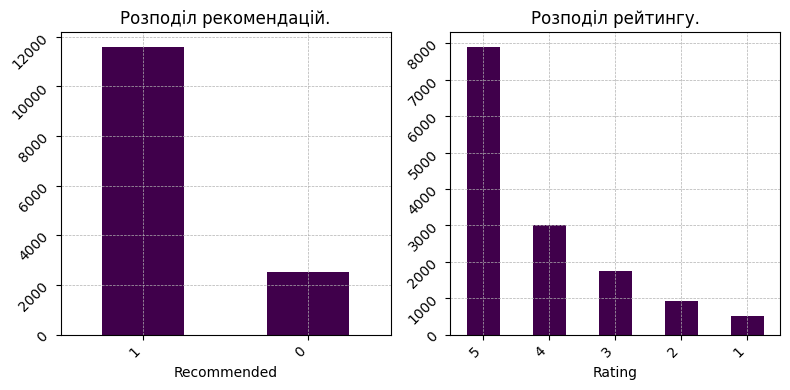

In [47]:
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.title('Розподіл рекомендацій.')
train_ds['Recommended'].value_counts().plot(kind='bar', cmap='PRGn')
plt.grid(linestyle = '--', linewidth = 0.5)
plt.yticks(rotation=45, ha="right")
plt.xticks(rotation=45, ha="right")

plt.subplot(1, 2, 2)
plt.title('Розподіл рейтингу.')
train_ds['Rating'].value_counts().plot(kind='bar', cmap='PRGn')
plt.grid(linestyle = '--', linewidth = 0.5)
plt.yticks(rotation=45, ha="right")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

Маємо дисбаланс таргетів який буде враховано при навчанні моделей.

In [26]:
train_ds.isna().sum()

Id                     0
Age                    0
Review_Title        2359
Review               503
Pos_Feedback_Cnt       0
Division              11
Department            11
Product_Category      11
Rating                 0
Recommended            0
dtype: int64

Review_Title має більше NaN значень, але це не найважливіша ознака.  
NaN значення заміню на порожній рядок '' і створю нову ознаку  
'full_review' де поєднаю інформацію з двох цих ознак, title та review.  

Спочатку працювати будемо з ознакою full_review, щоб подивитись як модель розуміє мову.  

Усі інші ознаке не будуть приймати участь у даному навчанні.  
Це буде робитися з метою опрацювання саме тексту, щоб модель не відволікалася,  
і не чіплялася за категоріальні або числові ознаки.   

Далі спробуємо провести навчання за іншими ознаками.

In [9]:
train = train_ds.copy()

In [10]:
train['full_review'] = train['Review_Title'].fillna('') + ' ' + train['Review']

In [11]:
train['full_review'].isna().sum()

np.int64(503)

In [12]:
train_review = train.copy()

In [13]:
train_review = train_review.drop(['Id', 
                                  'Age', 
                                  'Review_Title', 
                                  'Review', 
                                  'Pos_Feedback_Cnt', 
                                  'Division', 
                                  'Department', 
                                  'Product_Category'], axis=1)

In [14]:
train_review = train_review.dropna(subset='full_review')
train_review.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13588 entries, 0 to 14090
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Rating       13588 non-null  int64 
 1   Recommended  13588 non-null  int64 
 2   full_review  13588 non-null  object
dtypes: int64(2), object(1)
memory usage: 424.6+ KB


Датасет у такому форматі використаємо для навчання по відгуках.

# Bag-of-Words
## BoW

Проведемо узгоджену обробку тексту для цього підходу.  
 - Приберемо дивну пунктуацію та приведемо все до одного регістру.
 - Скористаємося бібліотекою Spacy яка робить токенізацію, лематизацію,  
   та позбудемося 'стоп-слів'.

In [18]:
nlp = spacy.load('en_core_web_sm')

In [19]:
def bow_cleaning(text):

    if not isinstance(text, str):
        return ''

    text_lower = text.lower().strip()
    
    text_clean = re.sub(r'[^a-z\s]', '', text_lower)

    doc = nlp(text_clean)

    processed_tokens = [token.lemma_ for token in doc if not token.is_stop]

    return ' '.join(processed_tokens)

У цій функції text_cleaning, яка приймає кожен відгук з ознаки full_review,  
спочатку робиться перевірка чи не порожнє значення ми отримали,  
потім приводиться все до одного регістру, всі літери стають маленькими (lower()) і прибираємо зайві пробіли, якщо такі є (strip()),  
отримуємо text_lower.  
Далі видаляємо все зайве, що не є латинською літерою або пробілом,  
отримуємо text_clean.  

Далі, для роботи з бібліотекою spaCy створюється ключовий для неї об'єкт doc.  
Наступним етапом, для кожного токена в об'єкті doc буде проведена лематизіція,  
якщо цей токен не є стоп-словом (словник стоп-слів вже є частиною бібліотеки spacy, тож не потребує окремого завантаження).

Функція повертає чистий рядок токенів.

In [20]:
train_bow_rev = train_review.copy()

In [21]:
train_bow_rev['clean_text'] = train_bow_rev['full_review'].apply(bow_cleaning)

In [22]:
train_bow_rev.head()

,Rating,Recommended,full_review,clean_text
0,5,1,Cute fall/holiday top Love this top! the quali...,cute fallholiday love quality magnificent patt...
2,2,0,"Disappointed Sleeves were tight, was difficult...",disappoint sleeve tight difficult price want...
3,5,1,Gorgeous detailing I never write reviews but t...,gorgeous detail write review clothe fantastic ...
4,5,1,Cute and comfortable tee! Love this tshirt! ca...,cute comfortable tee love tshirt casual clothe...
5,2,0,Disappointed I was so smitten by this shirt wh...,disappoint smite shirt see online love embroid...


# RNN
### File Preproccessing

Як вже зазначалось вище, модель RNN розрізняє послідовність слів, в цьому випадку, вона навіть дуже важлива, щоб модель спіймала контекст.  
Тому стоп-слова лишимо як є.  
І для векторизації буде використана TextVectorization.  
Цей інстрмент було створено спеціально для нейромереж.  
На виході ми отримаємо тензор з числами, які будуть відповідати ID слів у відгуку.  
Також таким чином буде збережено порядок цих слів, що є ключовим для RNN.

In [23]:
rnn_train_review = train_review.copy()

In [24]:
def rnn_cleaning(text):

  if not isinstance(text, str):
    return ''

  text_lower = text.lower().strip()

  text_clean = re.sub(r'[^a-z\s]', '', text_lower)

  doc = nlp(text_clean)

  processed_tokens = [token.lemma_ for token in doc]

  return " ".join(processed_tokens)

In [25]:
rnn_train_review['clean_text'] = rnn_train_review['full_review'].apply(rnn_cleaning)

In [26]:
rnn_train_review.head()

,Rating,Recommended,full_review,clean_text
0,5,1,Cute fall/holiday top Love this top! the quali...,cute fallholiday top love this top the quality...
2,2,0,"Disappointed Sleeves were tight, was difficult...",disappoint sleeve be tight be difficult to put...
3,5,1,Gorgeous detailing I never write reviews but t...,gorgeous detail I never write review but this ...
4,5,1,Cute and comfortable tee! Love this tshirt! ca...,cute and comfortable tee love this tshirt casu...
5,2,0,Disappointed I was so smitten by this shirt wh...,disappoint I be so smite by this shirt when I ...


# No Review Preproccessing

In [27]:
scaler = StandardScaler()

In [28]:
cat_features = ['Division', 'Department', 'Product_Category']

In [29]:
encoder_rec = ce.TargetEncoder(cols=cat_features, smoothing=10)
encoder_rat = ce.TargetEncoder(cols=cat_features, smoothing=10)

In [30]:
train_nr = train_ds.copy()
train_nr = train_nr.dropna(subset='Division')
train_nr = train_nr.drop(['Id', 'Review_Title', 'Review'], axis=1)
train_nr.info()

<class 'pandas.core.frame.DataFrame'>
Index: 14080 entries, 0 to 14090
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Age               14080 non-null  int64 
 1   Pos_Feedback_Cnt  14080 non-null  int64 
 2   Division          14080 non-null  object
 3   Department        14080 non-null  object
 4   Product_Category  14080 non-null  object
 5   Rating            14080 non-null  int64 
 6   Recommended       14080 non-null  int64 
dtypes: int64(4), object(3)
memory usage: 880.0+ KB


In [31]:
train_nr[['Age', 'Pos_Feedback_Cnt']] = scaler.fit_transform(train_nr[['Age', 'Pos_Feedback_Cnt']])

In [32]:
train_nr.head()

,Age,Pos_Feedback_Cnt,Division,Department,Product_Category,Rating,Recommended
0,-0.747028,-0.265685,General,Tops,Blouses,5,1
1,-0.664907,-0.446795,General,Tops,Blouses,5,1
2,-0.254301,2.269864,General,Tops,Blouses,2,0
3,-1.239754,0.096537,General Petite,Clothes,Clothes,5,1
4,-0.336422,-0.446795,General,Tops,Knits,5,1


In [33]:
X_enc_tr = train_nr.drop(['Rating', 'Recommended'], axis=1)

In [34]:
y_enc_rec = train_nr['Recommended']
y_enc_rat = train_nr['Rating']

In [36]:
rec_enc = encoder_rec.fit_transform(X_enc_tr, y_enc_rec)
rat_enc = encoder_rat.fit_transform(X_enc_tr, y_enc_rat)

In [37]:
rec_enc['Recomendation'] = y_enc_rec

In [38]:
rat_enc['Rating'] = y_enc_rat

In [39]:
train_bow, val_bow = train_test_split(train_bow_rev, test_size=0.2, random_state=16)
train_rnn, val_rnn = train_test_split(rnn_train_review, test_size=0.2, random_state=16)
train_rec_nr, val_rec_nr = train_test_split(rec_enc, test_size=0.2, random_state=16)
train_rat_nr, val_rat_nr = train_test_split(rat_enc, test_size=0.2, random_state=16)

In [40]:
# train_bow.to_csv('train_bow.csv', index=False)
# val_bow.to_csv('val_bow.csv', index=False)
# train_rnn.to_csv('train_rnn.csv', index=False)
# val_rnn.to_csv('val_rnn.csv', index=False)
# train_rec_nr.to_csv('train_rec_nr.csv', index=False)
# val_rec_nr.to_csv('val_rec_nr.csv', index=False)
# train_rat_nr.to_csv('train_rat_nr.csv', index=False)
# val_rat_nr.to_csv('val_rat_nr.csv', index=False)

### Підготуємо трохи тестовий датасет для обох підходів BoW та RNN

In [41]:
test_sub = test_ds.copy()

In [42]:
test_sub['full_review'] = test_sub['Review_Title'].fillna('') + ' ' + test_sub['Review']

In [43]:
test_bow = test_sub.copy()
test_rnn = test_sub.copy()

In [44]:
test_bow['clean_text'] = test_bow['full_review'].apply(bow_cleaning)
test_rnn['clean_text'] = test_rnn['full_review'].apply(rnn_cleaning)

In [45]:
test_bow = test_bow.drop(['Review_Title', 'Review', 'full_review'], axis=1)
test_rnn = test_rnn.drop(['Review_Title', 'Review', 'full_review'], axis=1)

In [46]:
test_bow.head()

,Id,Age,Pos_Feedback_Cnt,Division,Department,Product_Category,clean_text
0,21403,53,4,General,Clothes,Clothes,magnificent clothe contrast reviewer love clot...
1,22553,51,2,General,Clothes,Clothes,shapeless tent try store huge not try small si...
2,17436,59,1,General,Bottoms,Trousers,versatile think fun piece not realize versatil...
3,4293,48,1,General,Clothes,Clothes,simple cute buy multicolor stripe adorable ...
4,20149,46,0,Initmates,Intimate,Layering,magnificent simple tank wide strap style flatt...


In [47]:
test_rnn.head()

,Id,Age,Pos_Feedback_Cnt,Division,Department,Product_Category,clean_text
0,21403,53,4,General,Clothes,Clothes,magnificent clothe in contrast to the other re...
1,22553,51,2,General,Clothes,Clothes,shapeless tent I try this on in the store and ...
2,17436,59,1,General,Bottoms,Trousers,versatile and then some I think this be a fun ...
3,4293,48,1,General,Clothes,Clothes,so simple but so cute I buy the multicolor str...
4,20149,46,0,Initmates,Intimate,Layering,magnificent simple tank the wide strap style b...


Для випадків де відгуків не маємо, змушені навчатись за іншими ознаками.  
Подивимось, чи корелюється там хоч шось.

In [48]:
corr_check = train_ds.copy()

In [49]:
corr_check.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14091 entries, 0 to 14090
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Id                14091 non-null  int64 
 1   Age               14091 non-null  int64 
 2   Review_Title      11732 non-null  object
 3   Review            13588 non-null  object
 4   Pos_Feedback_Cnt  14091 non-null  int64 
 5   Division          14080 non-null  object
 6   Department        14080 non-null  object
 7   Product_Category  14080 non-null  object
 8   Rating            14091 non-null  int64 
 9   Recommended       14091 non-null  int64 
dtypes: int64(5), object(5)
memory usage: 1.1+ MB


In [50]:
corr_check = corr_check.drop(['Id', 'Review_Title', 'Review'], axis=1)
corr_check = corr_check.dropna(subset='Division')
corr_check.info()

<class 'pandas.core.frame.DataFrame'>
Index: 14080 entries, 0 to 14090
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Age               14080 non-null  int64 
 1   Pos_Feedback_Cnt  14080 non-null  int64 
 2   Division          14080 non-null  object
 3   Department        14080 non-null  object
 4   Product_Category  14080 non-null  object
 5   Rating            14080 non-null  int64 
 6   Recommended       14080 non-null  int64 
dtypes: int64(4), object(3)
memory usage: 880.0+ KB


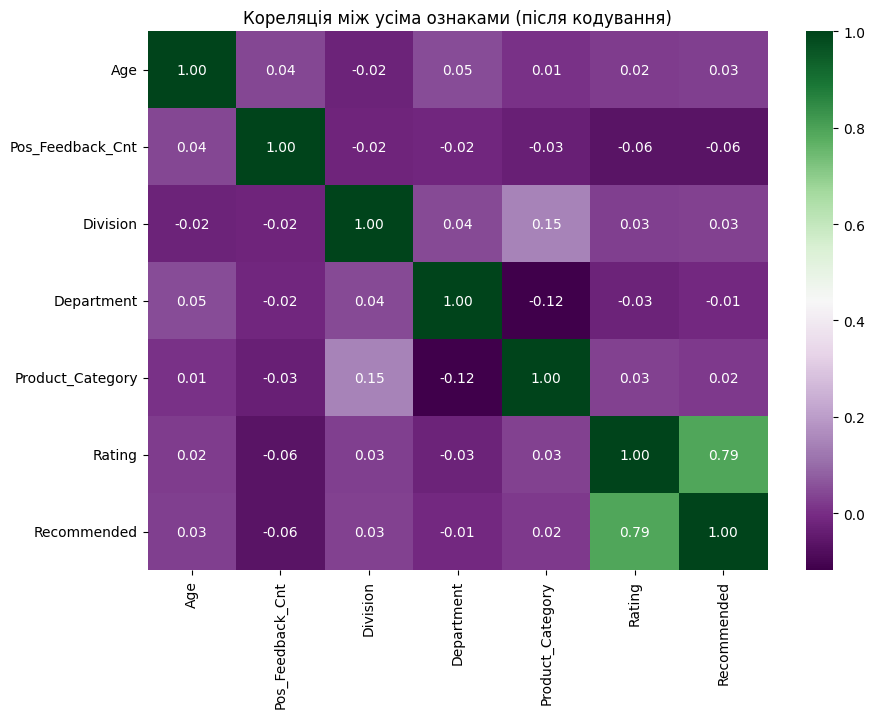

In [51]:
for col in corr_check.select_dtypes(include=['object']).columns:
    corr_check[col] = corr_check[col].astype('category').cat.codes

corr_matrix = corr_check.corr()
plt.figure(figsize=(10, 7))
sns.heatmap(corr_matrix, annot=True, cmap='PRGn', fmt='.2f')
plt.title('Кореляція між усіма ознаками (після кодування)')
plt.show()

Одразу можна сказати, що ми будемо мати погані результати,  
оскільки ознаки, такі як Age, Positive Feedback, Division, Department, Product_Category  
наврядчи сильно впливають на характер відгуку чи рейтинг.  
Матриця кореляцій тому підтвердження.

In [52]:
test_bow.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9395 entries, 0 to 9394
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Id                9395 non-null   int64 
 1   Age               9395 non-null   int64 
 2   Pos_Feedback_Cnt  9395 non-null   int64 
 3   Division          9392 non-null   object
 4   Department        9392 non-null   object
 5   Product_Category  9392 non-null   object
 6   clean_text        9395 non-null   object
dtypes: int64(3), object(4)
memory usage: 513.9+ KB


In [53]:
test_bow_review = test_bow[['Id', 'clean_text']]
test_rnn_review = test_rnn[['Id', 'clean_text']]

In [54]:
test_nr = test_bow.drop('clean_text', axis=1)

In [55]:
test_nr[['Age', 'Pos_Feedback_Cnt']] = scaler.transform(test_nr[['Age', 'Pos_Feedback_Cnt']])

In [56]:
test_rec_enc = encoder_rec.transform(test_nr.drop('Id', axis=1))

In [57]:
test_rat_enc = encoder_rat.transform(test_nr.drop('Id', axis=1))

In [58]:
# test_bow_review.to_csv('test_bow_review.csv', index=False)
# test_rnn_review.to_csv('test_rnn_review.csv', index=False)
# test_rec_enc.to_csv('test_rec_enc.csv', index=False)
# test_rat_enc.to_csv('test_rat_enc.csv', index=False)